## Project Description
- Objective of the project: Built a predictive model using customer data to identify individuals likely to churn. Additionally, leveraged model insights and historical data to analyze the characteristics of churned customers, enabling the development of targeted retention strategies.
  
- Process of the project:
  1. write a function to clean data in basis level
  2. EDA to understand the relationship of features
  3. Processing data: Numerical Feature scaling and split data
  4. Prediction model with Logistics Regression algorithm
  5. Prediction model with Decision algorithm
  6. Evaluation and extract important feature

## 1. Data Preparation

In [1]:
#import libs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline


In [2]:
def wrangle_func (file_path):
    df = pd.read_csv(file_path)
    #lower case column name
    df.columns = df.columns.str.lower().str.replace(' ','_')
    #lower case string values
    cat_cols = list(df.select_dtypes('object').columns)
    for col in cat_cols:
        df[col] = df[col].str.lower().str.replace(' ', '_')
    #change data types
    df['seniorcitizen'] = df['seniorcitizen'].astype('object')
    df['totalcharges'] = pd.to_numeric(df.totalcharges, errors ='coerce')
    #change data types of target variable to 1-0 type
    df.churn = (df.churn == 'yes').astype('int')
    #fill na in total charges by 0 
    df['totalcharges'].fillna(0)
    #drop customerid
    df.drop(columns='customerid',inplace = True)
    return df

In [3]:
#load data
file_path = 'data/telco_churn_rate.csv'

In [4]:
df =wrangle_func(file_path)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   seniorcitizen     7043 non-null   object 
 2   partner           7043 non-null   object 
 3   dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   object 
 6   multiplelines     7043 non-null   object 
 7   internetservice   7043 non-null   object 
 8   onlinesecurity    7043 non-null   object 
 9   onlinebackup      7043 non-null   object 
 10  deviceprotection  7043 non-null   object 
 11  techsupport       7043 non-null   object 
 12  streamingtv       7043 non-null   object 
 13  streamingmovies   7043 non-null   object 
 14  contract          7043 non-null   object 
 15  paperlessbilling  7043 non-null   object 
 16  paymentmethod     7043 non-null   object 


## 2. Explore Data

### 2.1 Target variable analysis

In [6]:
non_churn_rate, churn_rate = df['churn'].value_counts(normalize = True)

<Axes: title={'center': 'Class Balance of Churn and Non-Churn'}, xlabel='Class of Churn', ylabel='Relative Frequency'>

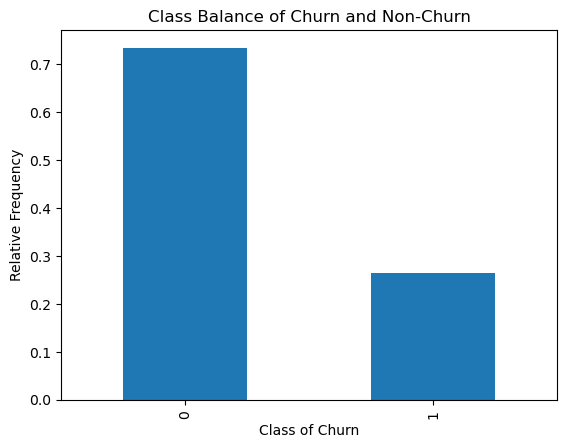

In [7]:
df['churn'].value_counts(normalize = True).plot(kind = 'bar', 
                                                xlabel = 'Class of Churn', 
                                                ylabel = 'Relative Frequency', 
                                                title = 'Class Balance of Churn and Non-Churn')

In this data_set, Majority of data is non-churn customers (73%)

### 2.2 Explore numeric features

In [8]:
correlation_df = df.select_dtypes('number').drop(columns ='churn').corr()

<Axes: >

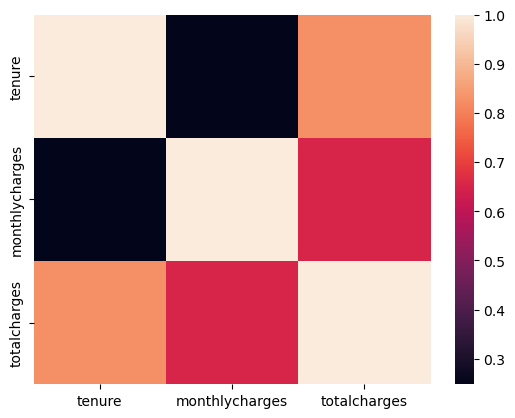

In [9]:
sns.heatmap(correlation_df)

This correlation table shows that the feature 'totalcharges' has strong correlation score with others, especially feature 'tenure'. Therefore, we need remove 'totalcharges' from the model to avoid multicollinearity

In [10]:
df.drop(columns ='totalcharges', inplace = True)

Review the difference of distribution of 'Monthlycharges' and 'tenture' by 'churn'

Text(0.5, 1.0, 'Distribution of Monnthly Charges by Class of Churn')

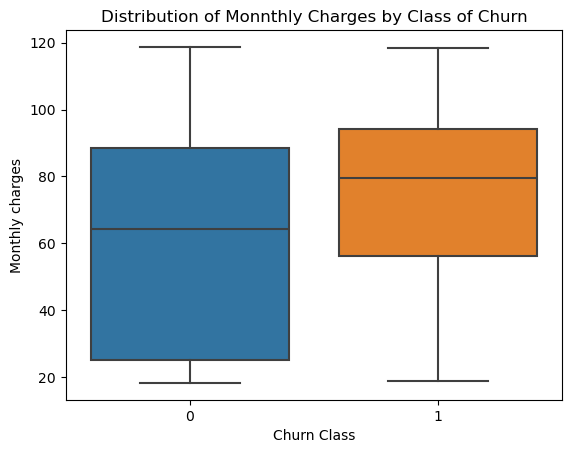

In [11]:
#Monthly Charges
sns.boxplot(x ='churn', y='monthlycharges', data = df)
plt.xlabel ('Churn Class')
plt.ylabel ('Monthly charges')
plt.title('Distribution of Monnthly Charges by Class of Churn')

From the distribution, we found that the churned customers have been paid higher monthly charges for the company. We need to consider the impact of 'monthly charges' to 'churn_rate'.

Text(0.5, 1.0, 'Distribution of Tenure by Class of Churn')

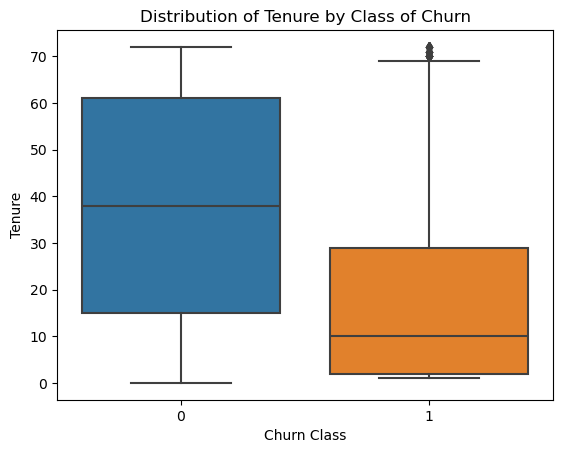

In [12]:
#Tenure
sns.boxplot(x ='churn', y='tenure', data = df)
plt.xlabel ('Churn Class')
plt.ylabel ('Tenure')
plt.title('Distribution of Tenure by Class of Churn')

It makes sense when the chart shows that the churned customers's tenure is lower than the non-churn's one

### 2.3 Explore categorical features

In [13]:
df.select_dtypes('object').nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

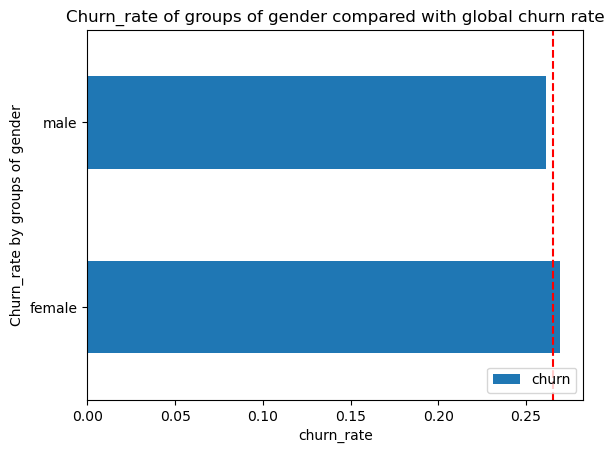

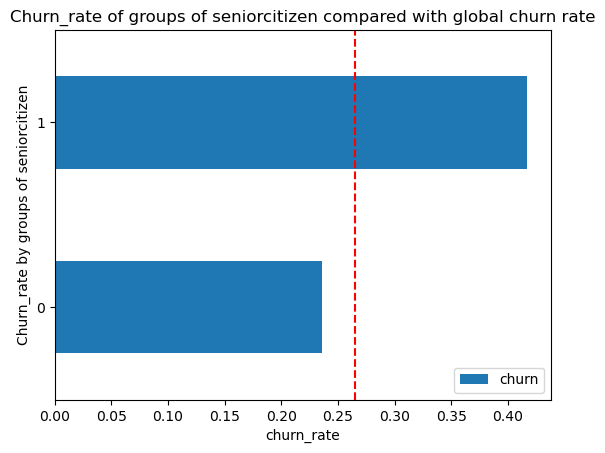

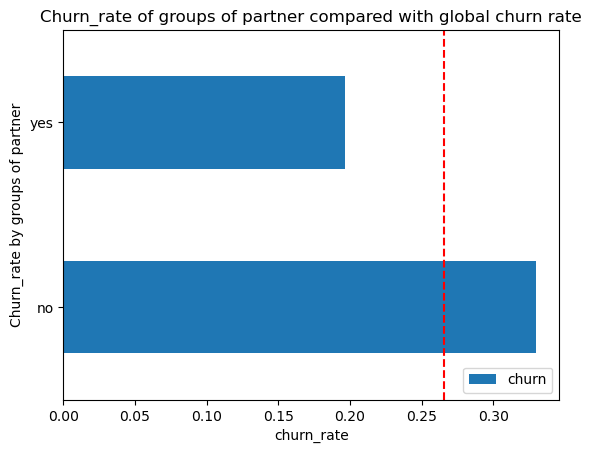

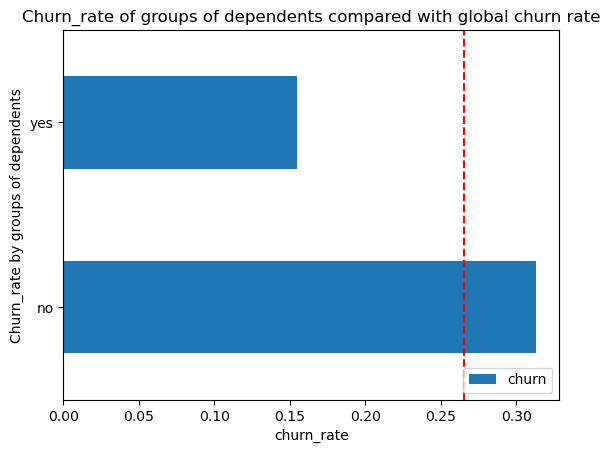

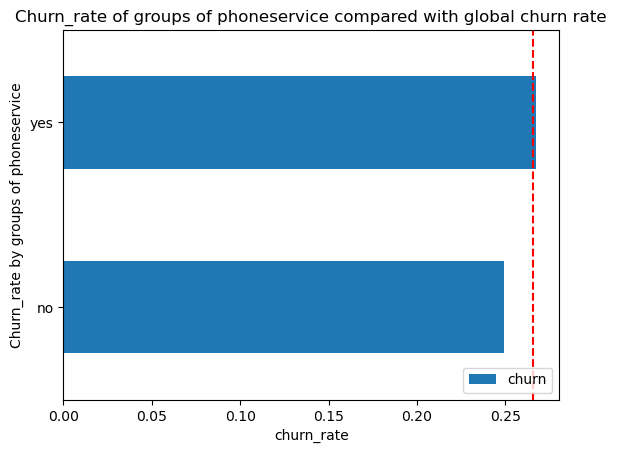

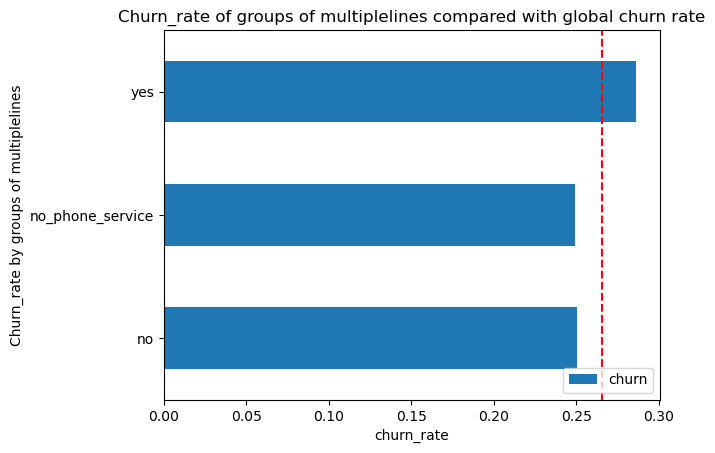

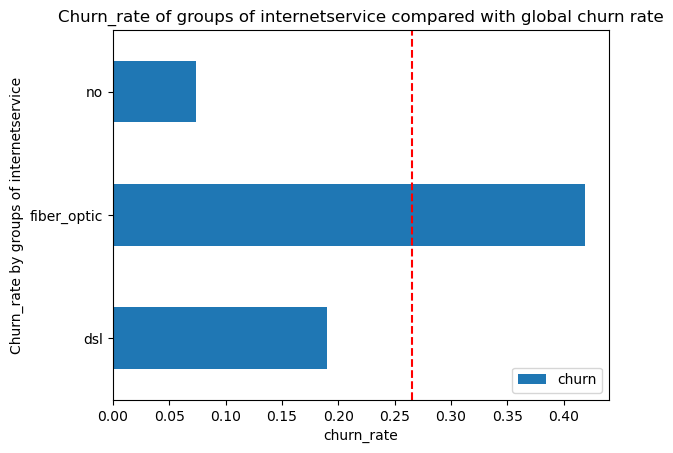

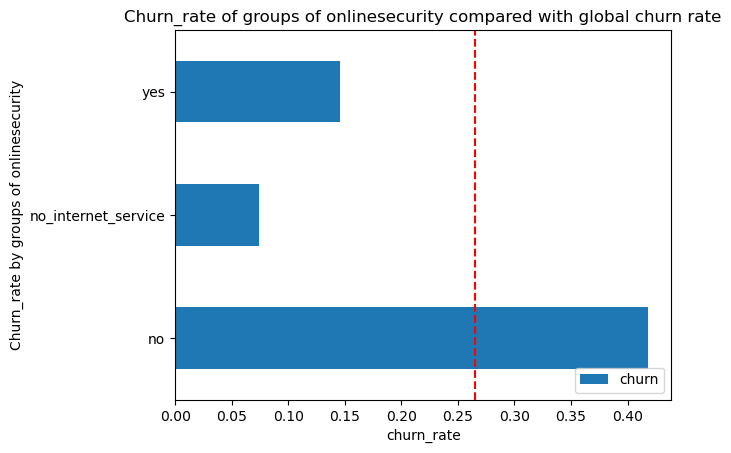

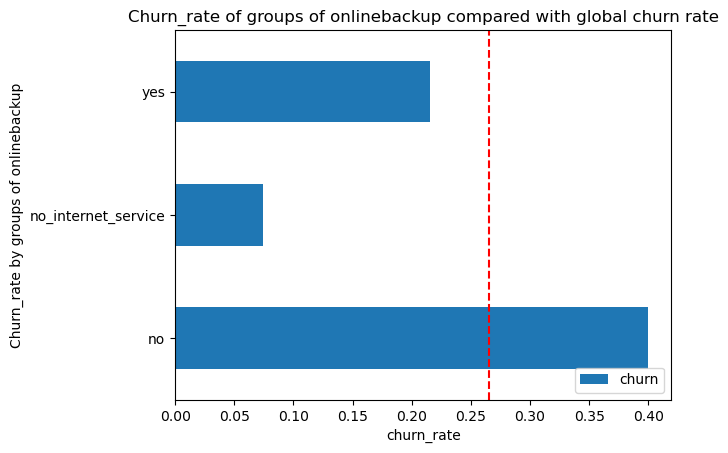

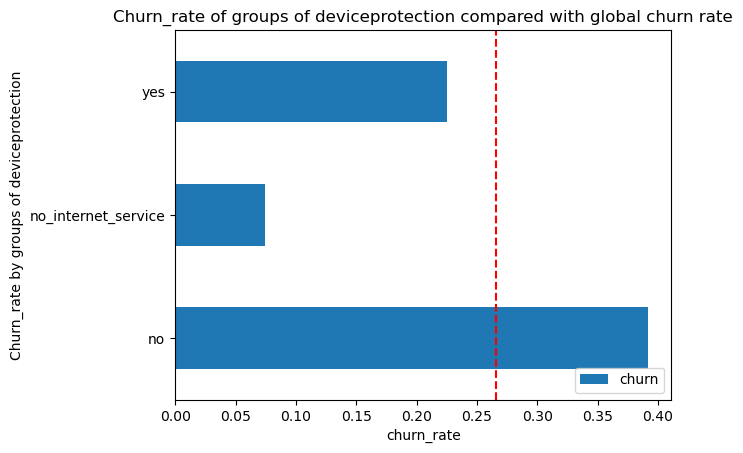

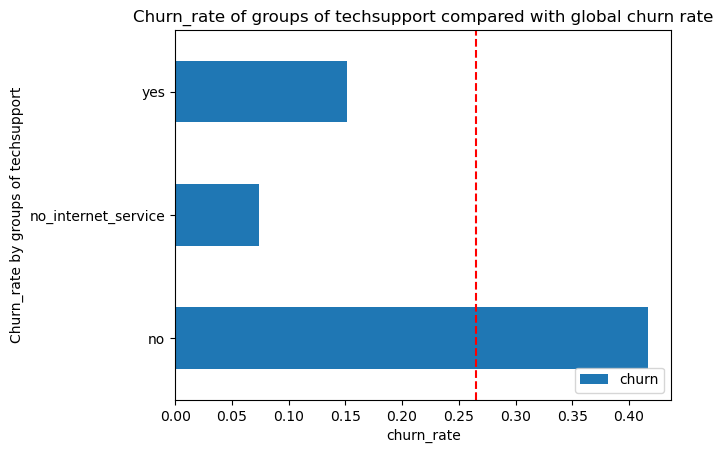

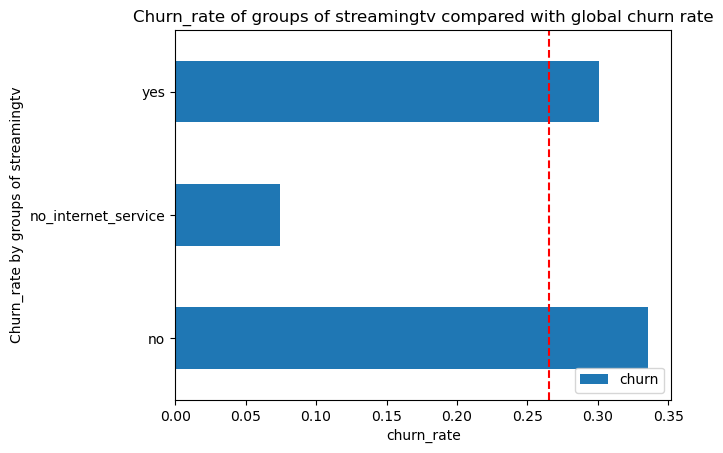

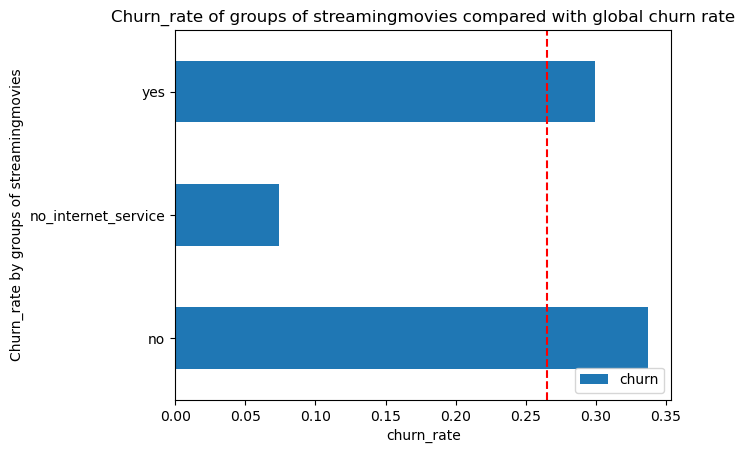

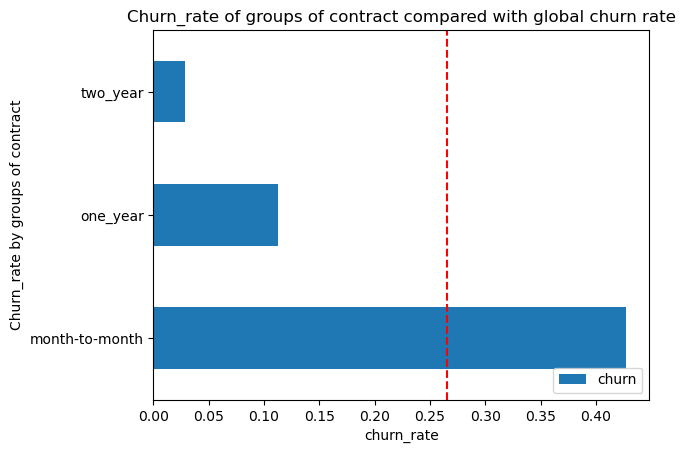

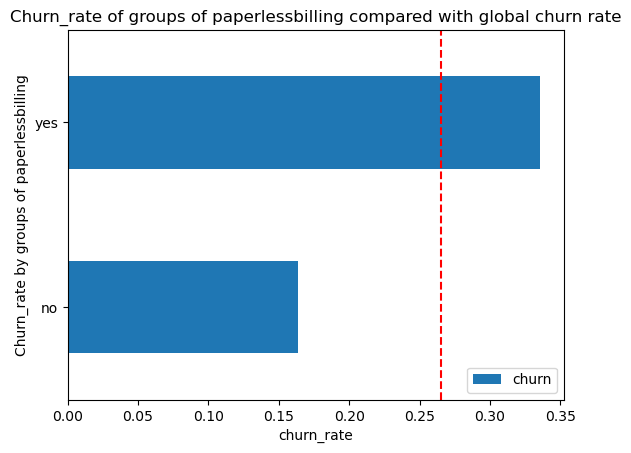

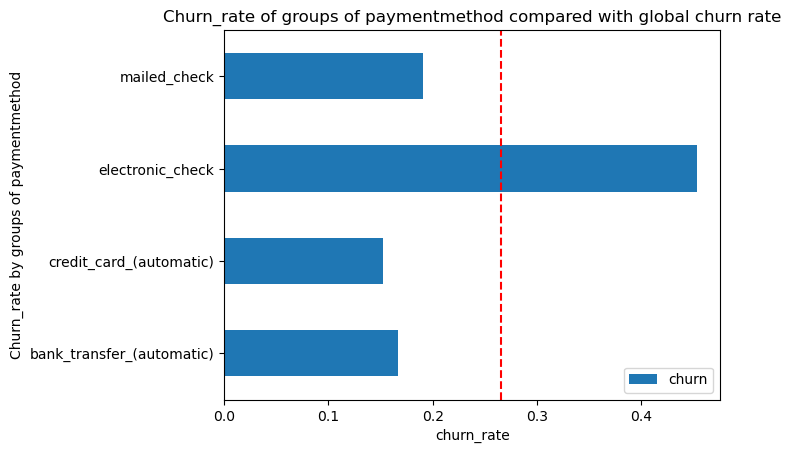

In [15]:
#Visualize churn_rate of specific groups compared with global churn rate to identify groups which have hight risk ratio
for col in df.columns:
    if (df[col].dtypes == 'object') and (col !='churn'):
        df_col = pd.pivot_table(df, index = col, values = 'churn', aggfunc ='mean')
        df_col.plot(kind = 'barh')
        plt.axvline(churn_rate, linestyle = '--', color = 'red')
        plt.xlabel('churn_rate')
        plt.ylabel(f'Churn_rate by groups of {col}')
        plt.title(f'Churn_rate of groups of {col} compared with global churn rate')
        plt.legend(loc ='lower right')
 

## 3. Data Processing

### 3.1 Features Scaling with Max-Min Normalization

In [16]:
#Normalize scales of Monthly charges and Tenure
scaler = MinMaxScaler()
data = df[['monthlycharges', 'tenure']]
df[['monthlycharges_scaled', 'tenure_scaled']] = scaler.fit_transform(data)

In [17]:
#drop monthlycharges, tenure columns
df.drop(columns =['monthlycharges', 'tenure'], inplace = True)

### 3.2 Split data 

In [18]:
target = 'churn'
X = df.drop('churn', axis = 1)
y = df[target]

In [19]:
#Split Train, Validation, Test with ratio 60:20:20

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.2, 
                                                    random_state = 42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, 
                                                    test_size = 0.2, 
                                                    random_state = 42)

## 4.Logistic Regression

### 4.1 Build Model

In [20]:
logistic_model = make_pipeline(
    OneHotEncoder(use_cat_names = True),
    LogisticRegression(max_iter = 1000)
)
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['gender', 'seniorcitizen', 'partner',
                                     'dependents', 'phoneservice',
                                     'multiplelines', 'internetservice',
                                     'onlinesecurity', 'onlinebackup',
                                     'deviceprotection', 'techsupport',
                                     'streamingtv', 'streamingmovies',
                                     'contract', 'paperlessbilling',
                                     'paymentmethod'],
                               use_cat_names=True)),
                ('logisticregression', LogisticRegression(max_iter=1000))])

### 4.2 Evaluation

In [21]:
#Train result
y_train_pred= logistic_model.predict(X_train)
train_accuracy_score = round(accuracy_score(y_train_pred, y_train),2)

In [22]:
#Validation set result:
y_val_pred= logistic_model.predict(X_val)
val_accuracy_score = round(accuracy_score(y_val_pred, y_val),2)

In [23]:
#Test set result:
y_test_pred = logistic_model.predict(X_test)
test_accuracy_score = round(accuracy_score(y_test_pred, y_test),2)

In [24]:
print('Train Accuracy: ', train_accuracy_score)
print('Test Accuracy: ', test_accuracy_score)

Train Accuracy:  0.8
Test Accuracy:  0.82


## 5. Decision Tree

### 5.1 Hyperparameter 

In [32]:
depth_hyperparams = range(1,33,2)

In [36]:
training_acc = []
validation_acc = []
for depth in depth_hyperparams:
    test_model = make_pipeline(OrdinalEncoder(), 
                              DecisionTreeClassifier(max_depth = depth, random_state=42)
    )
    test_model.fit(X_train, y_train)
    training_acc.append(accuracy_score(test_model.predict(X_train), y_train))
    validation_acc.append(accuracy_score(test_model.predict(X_val), y_val))


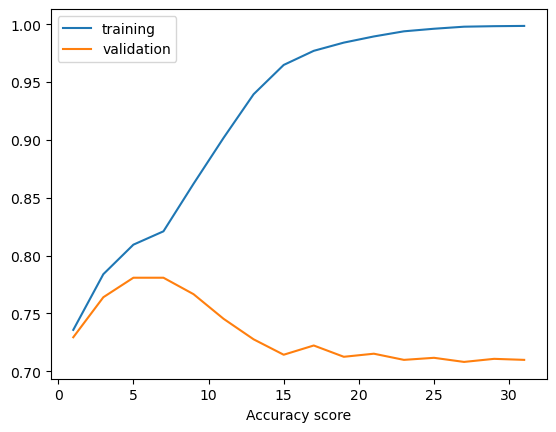

In [41]:
plt.plot(depth_hyperparams, training_acc, label= 'training')
plt.plot(depth_hyperparams, validation_acc, label= 'validation')
plt.xlabel("Max_depth")
plt.xlabel("Accuracy score")
plt.legend()

### 5.2 Buid Model wwith selected Hyperparameter

In [42]:
decision_tree_model = make_pipeline(
    OrdinalEncoder(), DecisionTreeClassifier(max_depth =5, random_state=42)
)
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('ordinalencoder',
                 OrdinalEncoder(cols=['gender', 'seniorcitizen', 'partner',
                                      'dependents', 'phoneservice',
                                      'multiplelines', 'internetservice',
                                      'onlinesecurity', 'onlinebackup',
                                      'deviceprotection', 'techsupport',
                                      'streamingtv', 'streamingmovies',
                                      'contract', 'paperlessbilling',
                                      'paymentmethod'],
                                mapping=[{'col': 'gender',
                                          'data_type': dtype('O'),
                                          'mappi...
month-to-month    3
NaN              -2
dtype: int64},
                                         {'col': 'paperlessbilling',
                                          'data_type': dtype('O'),
                                          'mapping': yes    1
no     2
NaN   -2
dtype: int64},
                                         {'col': 'paymentmethod',
                                          'data_type': dtype('O'),
                                          'mapping': mailed_check                 1
electronic_check             2
credit_card_(automatic)      3
bank_transfer_(automatic)    4
NaN                         -2
dtype: int64}])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [61]:
DT_train_accuracy = decision_tree_model.score(X_train, y_train)
DT_test_accuracy = decision_tree_model.score(X_test, y_test)

In [62]:
print('Train Accuracy: ', DT_train_accuracy)
print('Test Accuracy: ', DT_test_accuracy)

Train Accuracy:  0.8094075881961393
Test Accuracy:  0.7977288857345636


## 6. Final Result

As the result of 2 models, Logistic Regression retured better performance on both train and test set.

In [28]:

features = logistic_model.named_steps['onehotencoder'].get_feature_names_out()
importances = logistic_model.named_steps['logisticregression'].coef_[0]

In [29]:
#Put to a Series with pair (Feature and Coef). Convert Coefs which were applied sigmoid function in Logistic Regression 
feat_imp = pd.Series(np.exp(importances), index = features).sort_values()

<Axes: title={'center': 'The most important features'}>

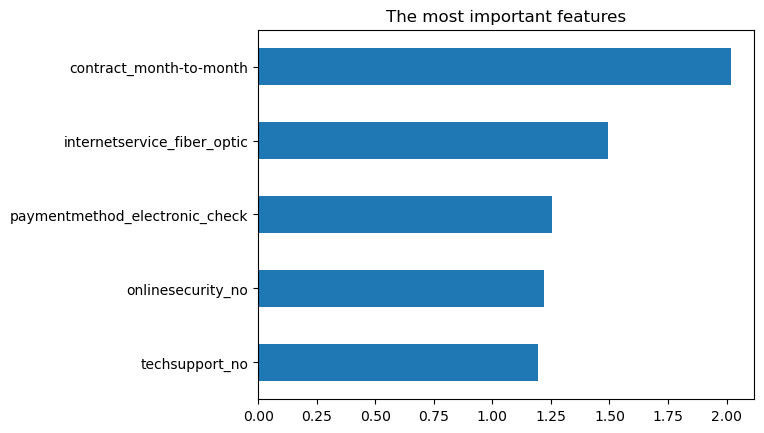

In [30]:
feat_imp.tail().plot(kind ='barh', title = 'The most important features')

<Axes: title={'center': 'The less important features'}>

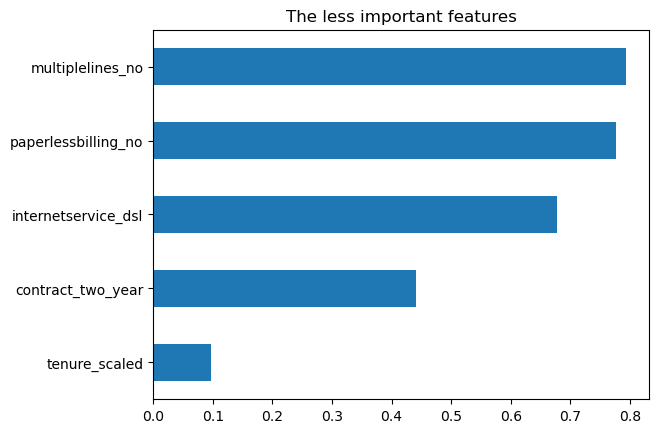

In [65]:
feat_imp.head().plot(kind ='barh', title = 'The less important features')

From the model, we can find that the key factors might affected to the customer's churn rate:
1. Contract Type: Month to Month
2. Internet Service: Fiber Optic
3. Payment Method: Electronic Check
4. Online Security: No
5. Tech support: No
<br>We can use the model to predict churn rate with the future data to estimate the churn rate and reflect to our strategy